In [17]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import math

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src" / "context_scaling" / "scripts"))
sys.path.insert(0, str(REPO_ROOT / "src"))

## Helpers

In [18]:
def get_wandb_table(
    tags,
    project="ideas_cv/llm-random-test",
    negative_tags=None,
    columns=None,
    print_columns=False,
):
    # WandB automatically looks for the WANDB_API_KEY environment variable.
    api = wandb.Api()

    print(f"tags: {tags}")

    if isinstance(tags, str):
        tags = [tags]

    # $and ensures the run contains ALL of the specified positive tags.
    filters = {"$and": [{"tags": tag} for tag in tags]} if tags else {}

    runs = api.runs(path=project, filters=filters)

    runs_data = []
    for run in runs:
        run_dict = {
            "sys/id": run.id,
            "sys/name": run.name,
            "sys/state": run.state,
            "sys/tags": run.tags,
        }
        run_dict.update({f"config/{k}": v for k, v in run.config.items()})
        run_dict.update({f"summary/{k}": v for k, v in run.summary._json_dict.items()})

        runs_data.append(run_dict)

    runs_table = pd.DataFrame(runs_data)

    if runs_table.empty:
        print("df shape: (0, 0)")
        return runs_table

    if columns:
        cols_to_keep = set(columns)
        if negative_tags:
            cols_to_keep.add("sys/tags")

        available_cols = [col for col in cols_to_keep if col in runs_table.columns]
        runs_table = runs_table[available_cols]

    if negative_tags:
        if isinstance(negative_tags, str):
            negative_tags = [negative_tags]

        for neg_tag in negative_tags:
            runs_table = runs_table[
                ~runs_table["sys/tags"].apply(
                    lambda x: neg_tag in x if isinstance(x, list) else False
                )
            ]

    if print_columns:
        print("\n=== Available columns ===")
        for col in sorted(runs_table.columns):
            print(f"\t{col}")
        print("========================\n")

    print(f"df shape: {runs_table.shape}")

    return runs_table


def solve_config_lr(
    config_lr: float,
) -> tuple[
    float, float
]:  # TODO temporary place - move to devinitions eval+ when created
    ret_lr, ret_exp_lr = None, None
    if config_lr < 1.0:
        ret_lr = config_lr
        ret_exp_lr = -1 * math.log(config_lr) / math.log(2)
    if config_lr >= 1.0:
        ret_lr = 2**-config_lr
        ret_exp_lr = ret_exp_lr
    return ret_lr, ret_exp_lr


def flatten_config_columns(df: pd.DataFrame, sep: str = "/") -> pd.DataFrame:
    """Expand dict-valued `config/*` columns into flat columns.

    wandb stores the nested OmegaConf config, so `run.config.items()` yields
    top-level keys like `common`, `trainer` with dict values. This walks those
    dicts and produces columns like `config/trainer/learning_rate`.
    """
    df = df.copy()

    def walk(prefix, value, out):
        if isinstance(value, dict):
            for k, v in value.items():
                walk(f"{prefix}{sep}{k}", v, out)
        else:
            out[prefix] = value

    config_cols = [c for c in df.columns if c.startswith("config/")]
    new_rows = []
    for _, row in df.iterrows():
        flat = {}
        for c in config_cols:
            walk(c, row[c], flat)
        new_rows.append(flat)

    flat_df = pd.DataFrame(new_rows, index=df.index)
    df = df.drop(columns=config_cols)
    return pd.concat([df, flat_df], axis=1)

In [19]:
def get_final_loss_values(runs_table, lr_col, loss_col, main_variables):
    rows = []
    for _, run_row in runs_table.iterrows():
        row = {
            "run_id": run_row["sys/id"],
            "lr": run_row[lr_col],
            "final_loss": run_row[loss_col],
        }
        for i, mv in enumerate(main_variables):
            row[f"grid_val_{i}"] = run_row[mv]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_loss_vs_lr(
    runs_table,
    main_variables,
    lr_col="config/trainer/learning_rate",
    loss_col="summary/steps/eval/loss",
    n_steps_col="config/trainer/n_steps",
    step_col="summary/step",
    ylim=None,
    title=None,
    ax=None,
    ax_labels_font=12,
    tick_font=12,
    title_font=12,
    var_labels=None,
    color_map=None,
    legend_loc="best",
):
    """Plot final eval loss vs learning rate, one line per `main_variables` combo.

    Expects a wandb-style dataframe (columns prefixed `config/` and `summary/`).
    Finished runs (step+1 >= n_steps) are drawn with circles + solid lines;
    running runs are drawn with squares + dashed lines.

    `color_map`, if given, maps grid-value tuples to colors so multiple calls
    can share a consistent palette across subplots.
    """
    color_dict = {
        0: "#1f78b4",
        1: "#33a02c",
        2: "#e31a1c",
        3: "#ff7f00",
        4: "#6a3d9a",
        5: "#a65628",
        6: "#000000",
    }

    required = ["sys/id", lr_col, loss_col, n_steps_col, step_col, *main_variables]
    missing = [c for c in required if c not in runs_table.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    final_loss_df = get_final_loss_values(
        runs_table, lr_col=lr_col, loss_col=loss_col, main_variables=main_variables
    )
    final_loss_df = final_loss_df[final_loss_df["final_loss"].notnull()]

    completion_map = {
        r["sys/id"]: "complete" if (r[step_col] + 1 >= r[n_steps_col]) else "running"
        for _, r in runs_table.iterrows()
    }
    final_loss_df["status"] = final_loss_df["run_id"].map(completion_map)

    grid_cols = [f"grid_val_{i}" for i in range(len(main_variables))]
    grid_val_sets = (
        final_loss_df[grid_cols]
        .drop_duplicates()
        .sort_values(grid_cols)
        .itertuples(index=False, name=None)
    )

    var_labels = var_labels or {}

    for color_num, grid_vals in enumerate(grid_val_sets):
        mask = (final_loss_df[grid_cols] == grid_vals).all(axis=1)
        subset = final_loss_df[mask]
        color = (
            color_map.get(grid_vals)
            if color_map is not None
            else color_dict.get(color_num)
        )

        label = ", ".join(
            f"{var_labels.get(name, name)}: {value}"
            for name, value in zip(main_variables, grid_vals)
        )

        target = ax if ax is not None else plt

        finished = subset[subset["status"] == "complete"]
        if not finished.empty:
            means = finished.sort_values("lr").groupby("lr")["final_loss"].mean()
            target.plot(
                means.index.to_numpy(),
                means.values,
                marker="o",
                color=color,
                label=label,
                linestyle="-",
            )

        running = subset[subset["status"] != "complete"]
        if not running.empty:
            means = running.sort_values("lr").groupby("lr")["final_loss"].mean()
            target.plot(
                means.index.to_numpy(),
                means.values,
                marker="s",
                color=color,
                label=label,
                linestyle="--",
                markersize=6,
            )

    if ax is None:
        plt.legend(loc=legend_loc)
        plt.tick_params(axis="both", labelsize=tick_font)
        plt.xlabel("Learning Rate", fontsize=ax_labels_font)
        plt.ylabel("Final Eval Loss", fontsize=ax_labels_font)
        plt.title(title or "Final Loss vs Learning Rate", fontsize=title_font)
        plt.grid(True)
        plt.xscale("log", base=2)
        if ylim is not None:
            plt.ylim(ylim)
        plt.show()
    else:
        ax.legend(loc=legend_loc)
        ax.set_xlabel("Learning Rate", fontsize=ax_labels_font)
        ax.set_ylabel("Final Eval Loss", fontsize=ax_labels_font)
        ax.tick_params(axis="both", labelsize=tick_font)
        ax.set_xscale("log", base=2)
        ax.set_title(title or "Final Loss vs Learning Rate", fontsize=title_font)
        ax.grid(True)
        if ylim is not None:
            ax.set_ylim(ylim)

In [20]:
KEEP_COLS_DEFAULT = [
    "sys/id",
    "sys/name",
    "sys/state",
    "sys/tags",
    "config/trainer/learning_rate",
    "config/trainer/n_steps",
    "config/common/batch_size",
    "config/common/dmodel",
    "summary/step",
    "summary/steps/eval/loss",
]


def augment_with_midway_loss(
    df,
    project,
    pcts=(50,),
    metric_key="steps/eval/loss",
    n_steps_col="config/trainer/n_steps",
    cache_path=None,
    keep_cols=None,
):
    """Add `eval@<pct>` columns for eval loss at each pct% through training.

    Cache: if `cache_path` exists, values are read from CSV first; wandb history is
    only fetched for runs missing the requested pcts. The augmented df is then
    written back to `cache_path` with `keep_cols + eval@<pct>` columns.
    """
    pcts = list(pcts)
    target_cols = [f"eval@{p}" for p in pcts]

    cache = pd.DataFrame()
    if cache_path is not None and Path(cache_path).exists():
        cache = pd.read_csv(cache_path)
    cache_by_id = (
        {row["sys/id"]: row.to_dict() for _, row in cache.iterrows()}
        if "sys/id" in cache.columns
        else {}
    )

    api = wandb.Api()
    new_vals = {col: [] for col in target_cols}

    for _, run_row in df.iterrows():
        run_id = run_row["sys/id"]
        cached = cache_by_id.get(run_id, {})
        n_steps = run_row[n_steps_col]

        history = None
        for pct, col in zip(pcts, target_cols):
            cached_val = cached.get(col, np.nan)
            if pd.notnull(cached_val):
                new_vals[col].append(cached_val)
                continue

            if history is None:
                run = api.run(f"{project}/{run_id}")
                history = run.history(keys=[metric_key], samples=10000, pandas=True)

            if metric_key not in history.columns:
                new_vals[col].append(np.nan)
                continue

            h = history.dropna(subset=[metric_key])
            if h.empty:
                new_vals[col].append(np.nan)
                continue

            target_step = int(n_steps * pct / 100)
            idx = (h["_step"] - target_step).abs().idxmin()
            new_vals[col].append(h.loc[idx, metric_key])

    df = df.copy()
    for col in target_cols:
        df[col] = new_vals[col]

    if cache_path is not None:
        cols = list(keep_cols or KEEP_COLS_DEFAULT) + target_cols
        cols = [c for c in cols if c in df.columns]
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        df[cols].to_csv(cache_path, index=False)

    return df

In [21]:
# Per-plot data-prep / plotting helpers (constants live in each plot's section cell).
def resolve_lr(df):
    # map raw config LR (x>=1 -> 2**-x) to the effective LR used in training
    df = df.copy()
    df["config/trainer/learning_rate"] = df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    return df


def prep_plot_df(df):
    plot_df = flatten_config_columns(df)  # config/trainer is a nested dict from wandb
    target = plot_df["config/trainer/_target_"].fillna("").astype(str)
    plot_df["method"] = np.where(
        target.str.contains("projected_compression.trainer"), "PC", "HP"
    )
    plot_df["distillation"] = target.str.contains("distillation", case=False)
    _labels = {
        ("PC", False): "pc",
        ("PC", True): "pc_distil",
        ("HP", False): "hp",
        ("HP", True): "hp_distil",
    }
    plot_df["config_type"] = [
        _labels[(m, d)] for m, d in zip(plot_df["method"], plot_df["distillation"])
    ]
    return resolve_lr(plot_df)


def classify_by_tags(tags):
    tags = set(tags)
    if "hard_pruning" in tags:
        method = "HP"
    elif "projected_compression" in tags:
        method = "PC"
    else:
        return None, None
    config_type = method + ("D" if "distillation" in tags else "")
    comp = next((c for c in COMPRESSION_RATE_LABELS if c in tags), None)
    return config_type, comp


def build_qwen_tokens_loss_df(
    tags=("qwen", "1.7B"),
    project="ideas_cv/llm-random-test",
    loss_col="summary/steps/100/train/loss",
    n_steps_col="config/trainer/n_steps",
):
    df = flatten_config_columns(get_wandb_table(list(tags), project=project))
    df = df[(df["sys/state"] == "finished") & df[loss_col].notnull()]
    df = df[df[n_steps_col].isin(TOKEN_LABELS)]

    rows = []
    for _, r in df.iterrows():
        config_type, comp = classify_by_tags(r["sys/tags"])
        if config_type is None or comp is None:
            continue
        rows.append(
            {
                "config_type": config_type,
                "compression_rate": COMPRESSION_RATE_LABELS[comp],
                "processed_tokens": TOKEN_LABELS[int(r[n_steps_col])],
                "loss": r[loss_col],
            }
        )

    long_df = pd.DataFrame(rows)
    # collapse LR sweeps / reruns to the best (lowest final loss) run per group
    return (
        long_df.sort_values("loss")
        .groupby(
            ["config_type", "compression_rate", "processed_tokens"], as_index=False
        )
        .first()
    )


def plot_loss_vs_tokens(
    df,
    title=None,
    ax_labels_font=18,
    tick_font=15,
    title_font=20,
    legend_loc="upper right",
    ylims=None,
):
    token_order = list(TOKEN_LABELS.values())
    comp_rates = ["50%", "70%", "90%"]
    # per-subplot y range keyed by compression rate; None -> autoscale
    ylims = ylims or {}

    # sharey=False -> each subplot gets its own independent y-axis
    fig, axes = plt.subplots(1, len(comp_rates), figsize=(24, 6), sharey=False)
    for ax, comp_rate in zip(axes, comp_rates):
        subset = df[df["compression_rate"] == comp_rate]
        for config_type in CONFIG_TYPE_ORDER:
            line = (
                subset[subset["config_type"] == config_type]
                .set_index("processed_tokens")
                .reindex(token_order)
                .dropna(subset=["loss"])
            )
            if line.empty:
                continue
            ax.plot(
                line.index,
                line["loss"],
                marker="o",
                color=CONFIG_TYPE_COLORS[config_type],
                label=config_type,
            )
        ax.set_xlabel("Processed tokens", fontsize=ax_labels_font)
        ax.set_ylabel("Loss", fontsize=ax_labels_font)
        ax.tick_params(axis="both", labelsize=tick_font)
        ax.set_title(f"Compression rate: {comp_rate}", fontsize=title_font)
        ax.grid(True)
        ax.legend(loc=legend_loc, fontsize=tick_font, title="Method")
        if ylims.get(comp_rate) is not None:
            ax.set_ylim(ylims[comp_rate])

    if title:
        fig.suptitle(title, fontsize=title_font + 2)
    fig.tight_layout()
    plt.show()


def prep_proj_lr_df(df):
    plot_df = flatten_config_columns(df)
    # effective base LR (config LR x>=1 -> 2**-x), then scaled by the projection ratio
    base_lr = plot_df["config/trainer/learning_rate"].apply(
        lambda x: solve_config_lr(x)[0] if pd.notnull(x) else x
    )
    ratio = plot_df["config/projected_compression/pc_weights_lr_ratio"]
    plot_df["proj_lr"] = base_lr * ratio
    plot_df["base_lr"] = base_lr
    plot_df["comp_rate"] = plot_df["config/common/dmodel"].map(DMODEL_TO_COMP)
    return plot_df

## QWEN LR grid

In [22]:
# LR grids as a grid: rows = processed tokens, cols = compression rates.
# shared across the notebook
negative_tags = ["remove"]
project = "ideas_cv/llm-random-test"

# LR-grid defaults
token_tags = ["1B_train", "2B_train", "4B_train", "8B_train"]
pcts = ["50p", "30p", "10p"]
mv = "config_type"
loss_col = "summary/steps/100/train/loss"
palette = ["#5F0202", "#00336D", "#ff0004", "#006EFF"]
# fixed color per config_type so colors are consistent across the whole grid
all_config_types = ["hp", "hp_distil", "pc", "pc_distil"]
color_map = {(ct,): palette[i % len(palette)] for i, ct in enumerate(all_config_types)}
# per-column y limits (50p, 30p, 10p); edit the last entry for the 10% comp column
ylims = [(2.4, 3.4), (2.4, 3.4), (2.4, 3.4)]

tags: ['1.7B', 'qwen', '1B_train', '50p']
df shape: (35, 117)
tags: ['1.7B', 'qwen', '1B_train', '30p']
df shape: (21, 117)
tags: ['1.7B', 'qwen', '1B_train', '10p']
df shape: (21, 117)
tags: ['1.7B', 'qwen', '2B_train', '50p']
df shape: (8, 113)
tags: ['1.7B', 'qwen', '2B_train', '30p']
df shape: (8, 113)
tags: ['1.7B', 'qwen', '2B_train', '10p']
df shape: (8, 113)
tags: ['1.7B', 'qwen', '4B_train', '50p']
df shape: (8, 113)
tags: ['1.7B', 'qwen', '4B_train', '30p']
df shape: (8, 113)
tags: ['1.7B', 'qwen', '4B_train', '10p']
df shape: (8, 113)
tags: ['1.7B', 'qwen', '8B_train', '50p']
df shape: (8, 113)
tags: ['1.7B', 'qwen', '8B_train', '30p']
df shape: (8, 113)
tags: ['1.7B', 'qwen', '8B_train', '10p']
df shape: (8, 113)


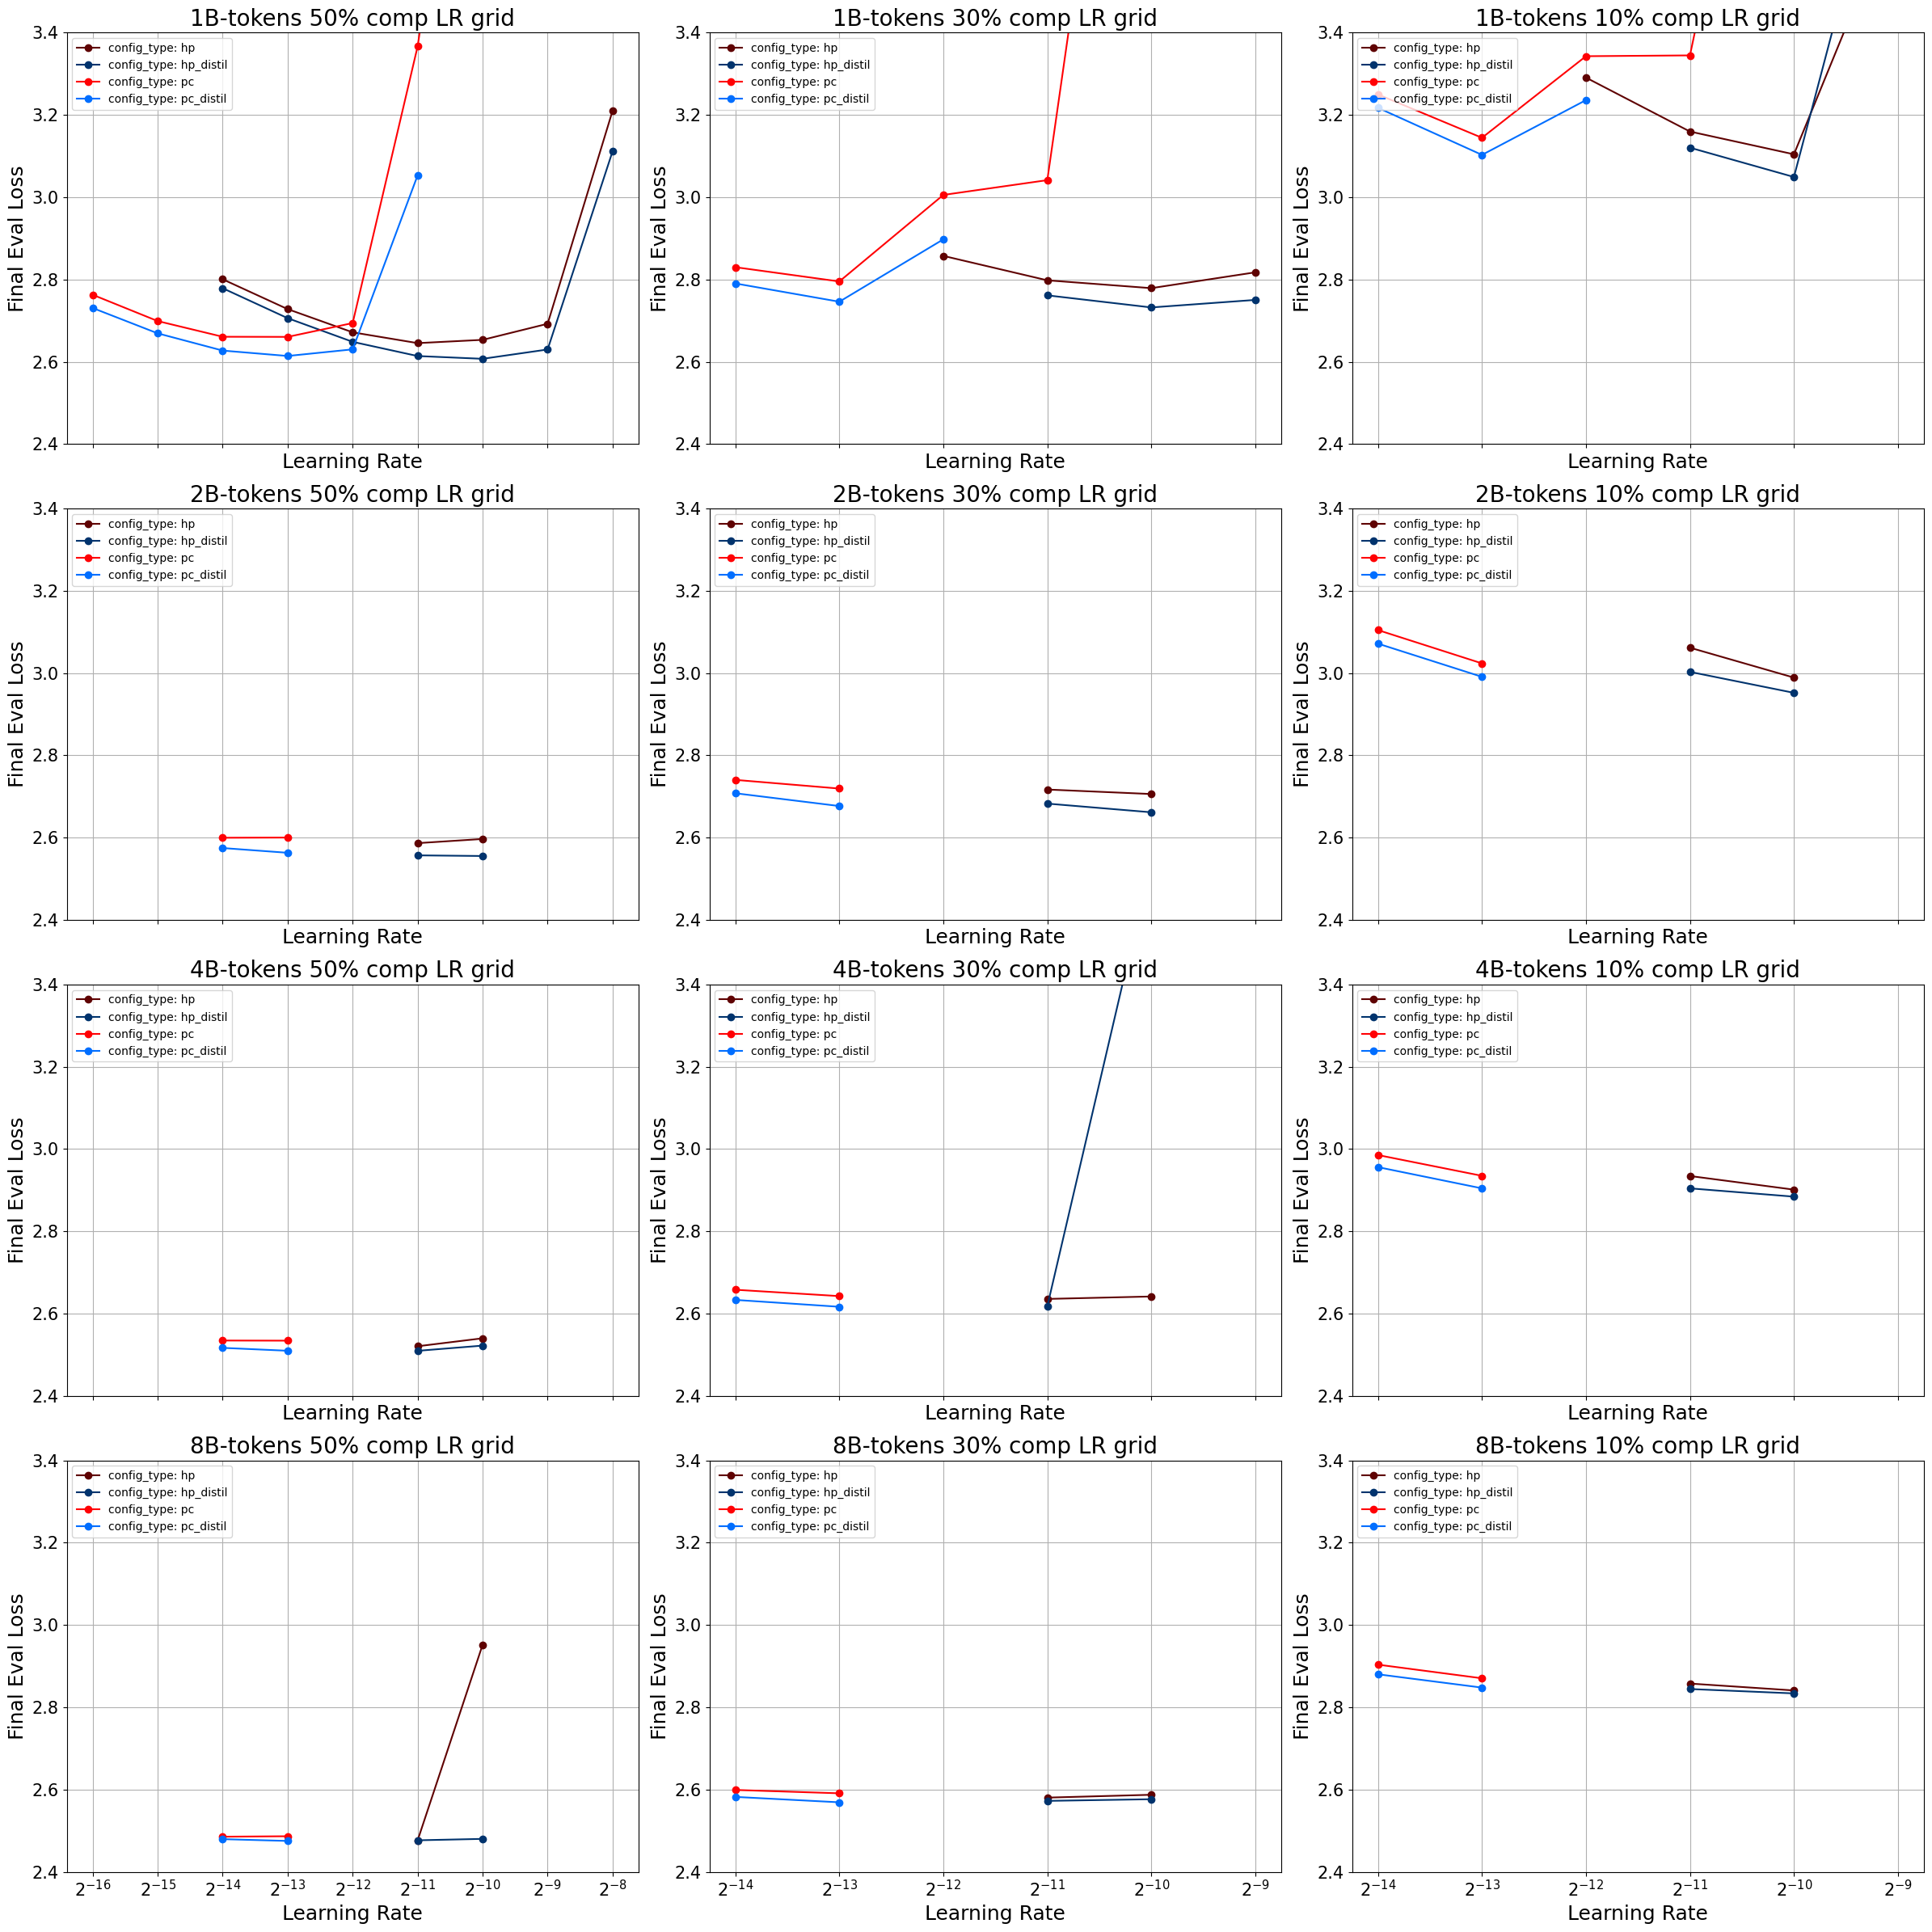

In [23]:
fig, axes = plt.subplots(
    len(token_tags),
    len(pcts),
    figsize=(24, 6 * len(token_tags)),
    sharey="col",
    sharex="col",
)
for row, token_tag in enumerate(token_tags):
    tokens_short = token_tag.split("_")[0]  # "1B_train" -> "1B"
    for col, pct in enumerate(pcts):
        ax = axes[row, col]
        tags = ["1.7B", "qwen", token_tag, pct]
        df = get_wandb_table(tags, project=project, negative_tags=negative_tags)
        if df.empty:
            ax.set_title(f"{tokens_short} {pct[:-1]}% comp (no runs)", fontsize=20)
            ax.set_xscale("log", base=2)
            ax.set_ylim(ylims[col])
            ax.grid(True)
            continue
        plot_df = prep_plot_df(df)
        plot_loss_vs_lr(
            plot_df,
            main_variables=[mv],
            loss_col=loss_col,
            legend_loc="upper left",
            title=f"{tokens_short}-tokens {pct[:-1]}% comp LR grid",
            ax_labels_font=18,
            tick_font=15,
            title_font=20,
            color_map=color_map,
            ax=ax,
            ylim=ylims[col],
        )

fig.tight_layout()
plt.show()

## QWEN PC vs HP loss vs processed tokens

One subplot per compression rate (90% / 70% / 50%), loss vs processed tokens,
one line per method (PC, PCD, HP, HPD). Reruns/LR-sweeps are collapsed to the
best (lowest final loss) run per (method, compression, tokens) group.

In [24]:
# Qwen: dmodel-tag -> compression rate, n_steps -> processed tokens.
COMPRESSION_RATE_LABELS = {"10p": "90%", "30p": "70%", "50p": "50%"}
TOKEN_LABELS = {2048: "1BT", 4096: "2BT", 8192: "4BT", 16384: "8BT"}
CONFIG_TYPE_ORDER = ["PC", "PCD", "HP", "HPD"]
CONFIG_TYPE_COLORS = {
    "PC": "#ff0004",
    "PCD": "#006EFF",
    "HP": "#5F0202",
    "HPD": "#00336D",
}
TOKENS_LOSS_TAGS = ("qwen", "1.7B")

In [25]:
qwen_tokens_loss_df = build_qwen_tokens_loss_df(tags=TOKENS_LOSS_TAGS)

tags: ['qwen', '1.7B']
df shape: (172, 117)


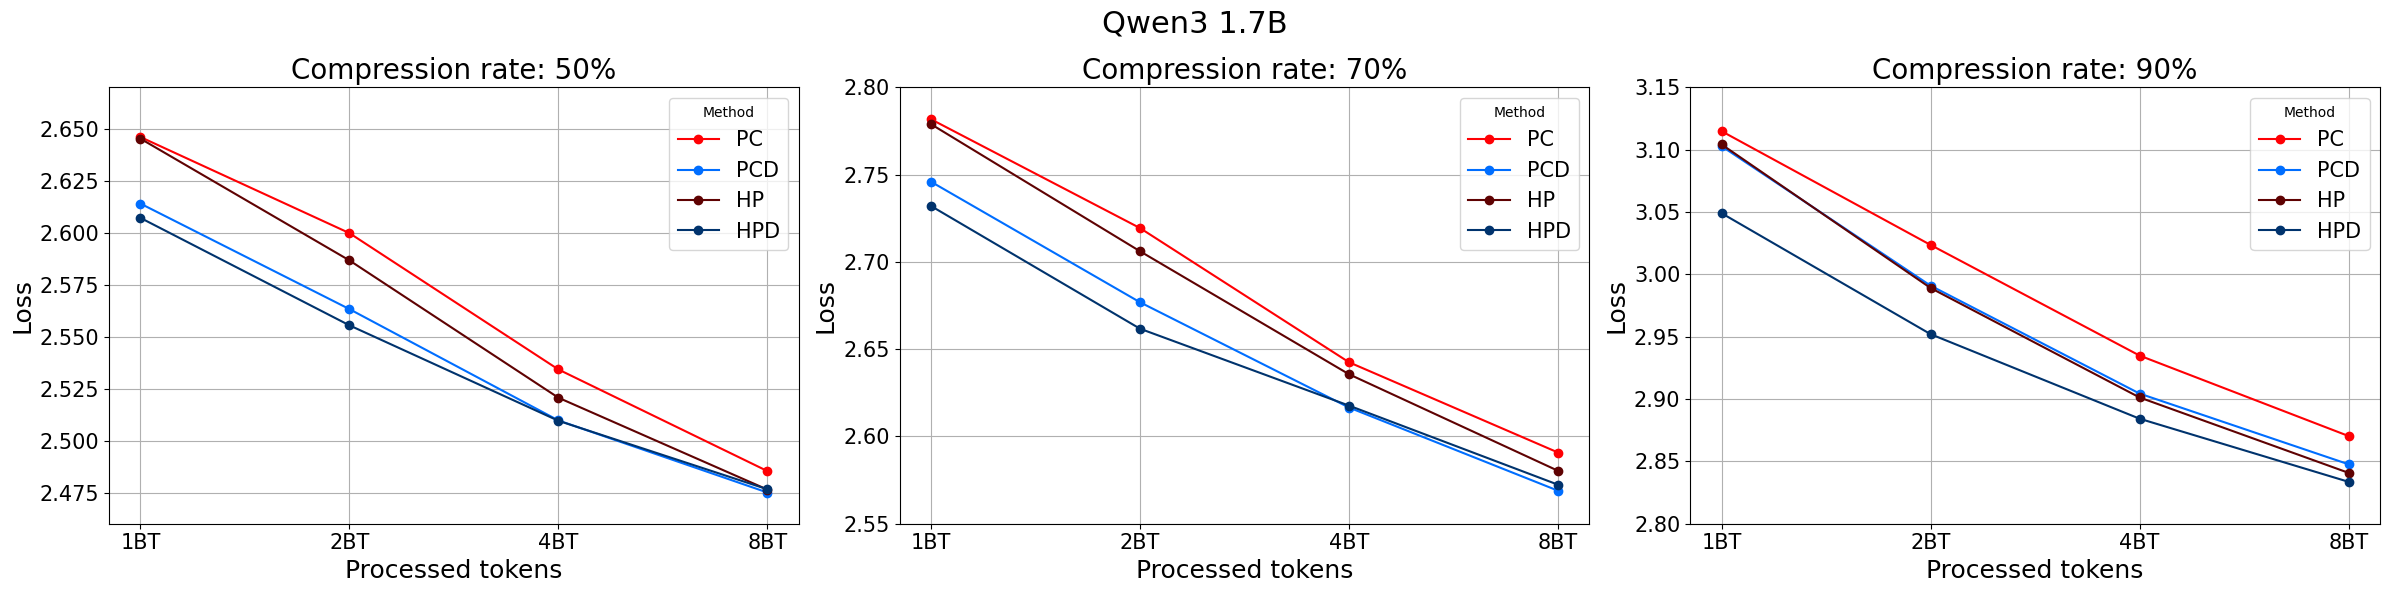

In [26]:
# per-subplot y range; tweak each entry independently
ylims = {"90%": (2.8, 3.15), "70%": (2.55, 2.8), "50%": (2.46, 2.67)}
plot_loss_vs_tokens(qwen_tokens_loss_df, title="Qwen3 1.7B", ylims=ylims)

## QWEN PC projection-matrix LR grid

Sweep over `pc_weights_lr_ratio` (the LR multiplier applied to the projection
matrices, not the aux weights). x-axis = **projection-matrix LR** = effective
base LR × `pc_weights_lr_ratio`; one line per (compression rate, base LR).
Everything on one picture. Runs selected by the `pc_weights_lr_ratio` tag.

In [27]:
# dmodel -> compression rate (see infrastructure.metric_logger tags in the config)
DMODEL_TO_COMP = {448: "90%", 960: "70%", 1344: "50%"}
COMP_RATES = ["90%", "70%", "50%"]
PROJ_LR_TAGS = ["qwen", "1.7B", "pc_weights_lr_ratio"]
PROJ_LR_LOSS_COL = "summary/steps/100/train/loss"
PROJ_YLIM = None  # e.g. (2.4, 3.4) to fix y range across subplots

tags: ['qwen', '1.7B', 'pc_weights_lr_ratio']
df shape: (24, 104)


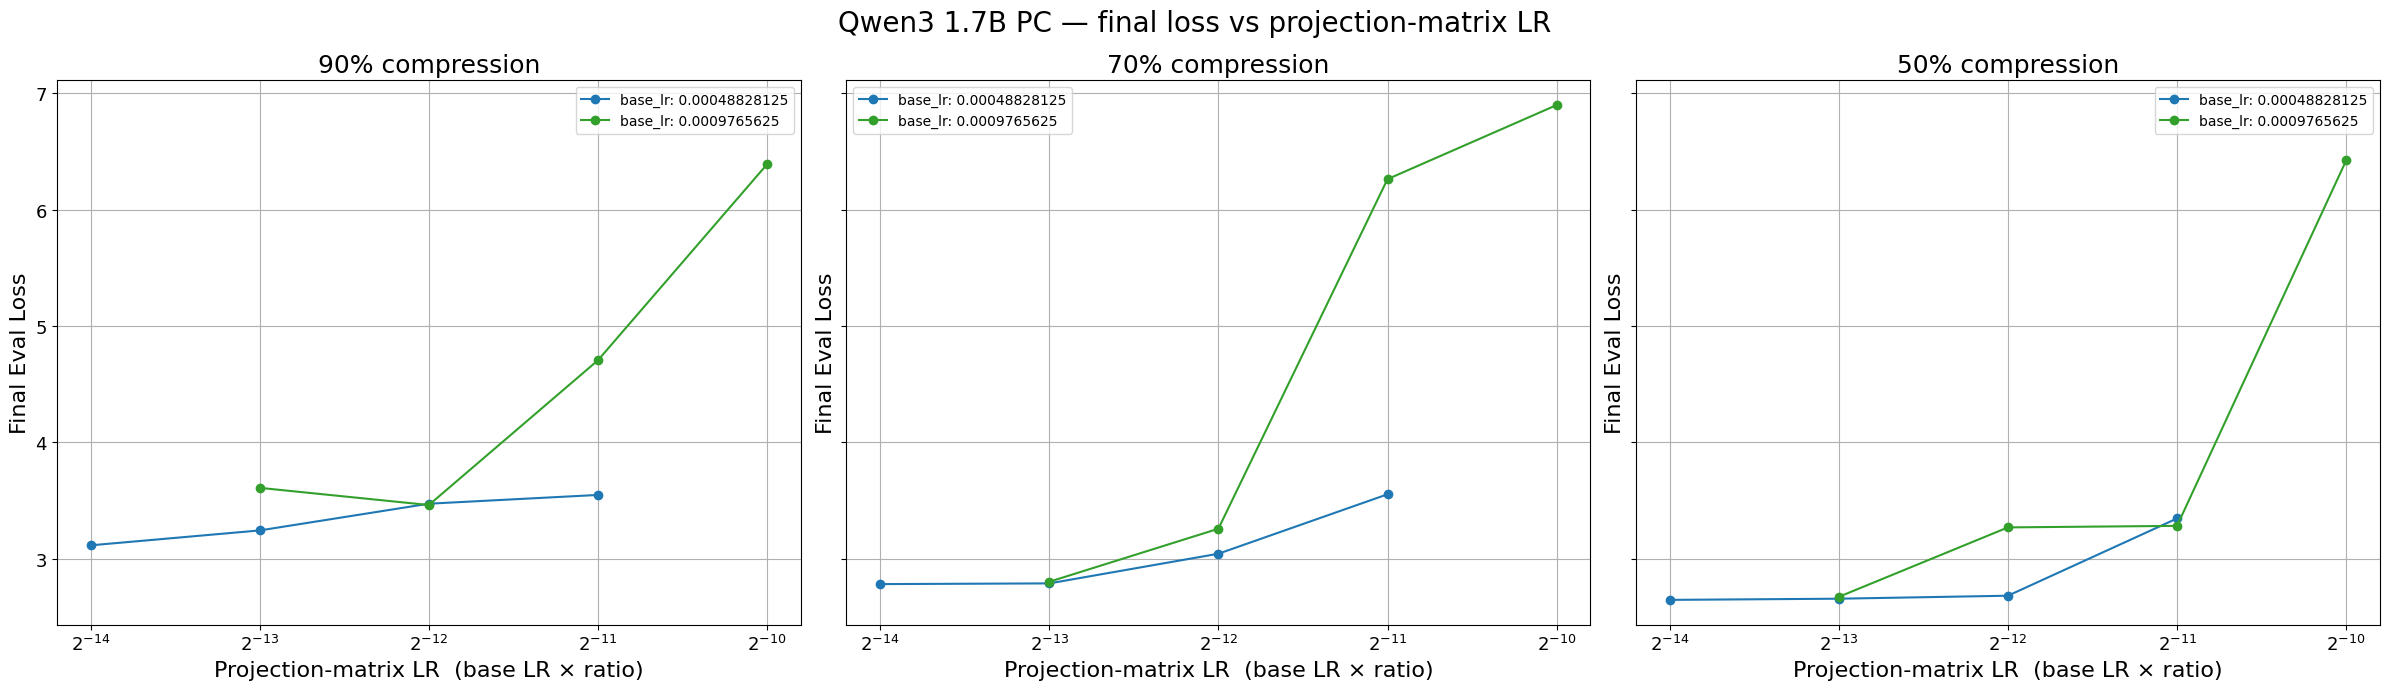

In [28]:
df = get_wandb_table(PROJ_LR_TAGS, project=project, negative_tags=negative_tags)
plot_df = prep_proj_lr_df(df)

# one subplot per compression rate; x-axis = projection-matrix LR, one line per base LR
fig, axes = plt.subplots(1, len(COMP_RATES), figsize=(8 * len(COMP_RATES), 7), sharey=True)
for ax, comp_rate in zip(axes, COMP_RATES):
    subset = plot_df[plot_df["comp_rate"] == comp_rate]
    if subset.empty:
        ax.set_title(f"{comp_rate} comp (no runs)", fontsize=18)
        ax.set_xscale("log", base=2)
        ax.grid(True)
        continue
    plot_loss_vs_lr(
        subset,
        main_variables=["base_lr"],
        lr_col="proj_lr",
        loss_col=PROJ_LR_LOSS_COL,
        var_labels={"base_lr": "base_lr"},
        title=f"{comp_rate} compression",
        ax=ax,
        legend_loc="best",
        ax_labels_font=16,
        tick_font=13,
        title_font=18,
        ylim=PROJ_YLIM,
    )
    ax.set_xlabel("Projection-matrix LR  (base LR × ratio)", fontsize=16)

fig.suptitle("Qwen3 1.7B PC — final loss vs projection-matrix LR", fontsize=20)
fig.tight_layout()
plt.show()